Veriler indiriliyor/yükleniyor...
Eğitim boyutu: (20000, 3072), Test boyutu: (2000, 3072)
Çapraz doğrulama (Cross-Validation) başlıyor... (Bu biraz zaman alabilir)
k=1 için ortalama doğruluk: 0.3039
k=3 için ortalama doğruluk: 0.2899
k=5 için ortalama doğruluk: 0.3016
k=8 için ortalama doğruluk: 0.3067
k=10 için ortalama doğruluk: 0.3047
k=15 için ortalama doğruluk: 0.3048
k=20 için ortalama doğruluk: 0.3034


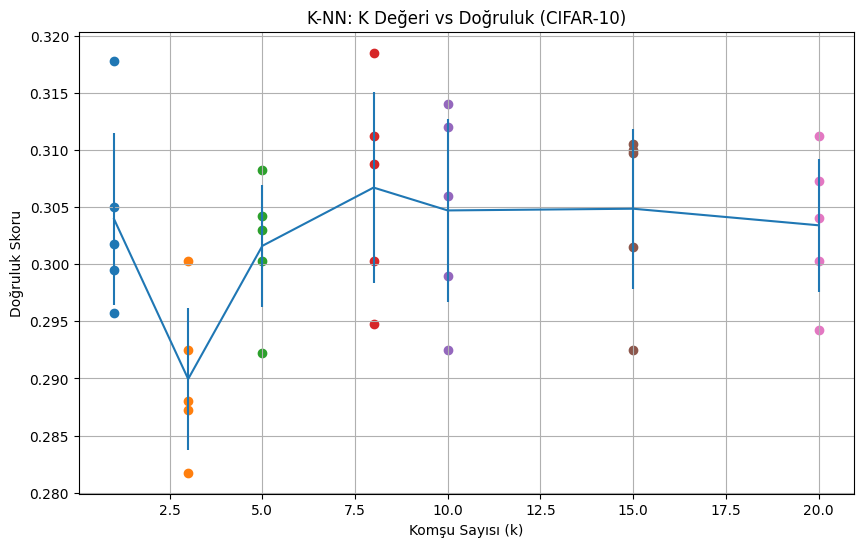


En iyi sonuç veren k: 8
Final Test Doğruluğu (%8 komşu ile): %30.55


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# --- 1. VERİ SETİNİ İÇERİ AKTARMA ---
# Görselleri Tensor formatına çeviriyoruz
transform = transforms.Compose([transforms.ToTensor()])

print("Veriler indiriliyor/yükleniyor...")
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# --- 2. VERİ ÖN İŞLEME (PREPROCESSING) ---
# K-NN 3D (32x32x3) görüntüleri anlamaz, onları tek bir satır (3072 piksel) yapmalıyız.
# Ayrıca RAM ve zaman tasarrufu için eğitimden 5000, testten 500 örnek alıyoruz.

X_train = train_set.data[:20000].reshape(20000, 3072).astype('float32') / 255.0
y_train = np.array(train_set.targets[:20000])

X_test = test_set.data[:2000].reshape(2000, 3072).astype('float32') / 255.0
y_test = np.array(test_set.targets[:2000])

print(f"Eğitim boyutu: {X_train.shape}, Test boyutu: {X_test.shape}")

# --- 3. HİPERPARAMETRE OPTİMİZASYONU (K DEĞERİ SEÇİMİ) ---
k_choices = [1, 3, 5, 8, 10, 15, 20]
k_to_accuracies = {}

print("Çapraz doğrulama (Cross-Validation) başlıyor... (Bu biraz zaman alabilir)")
for k in k_choices:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-Katlı Çapraz Doğrulama ile her k için doğruluk hesaplıyoruz
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    k_to_accuracies[k] = scores
    print(f"k={k} için ortalama doğruluk: {np.mean(scores):.4f}")

# --- 4. SONUÇLARIN GÖRSELLEŞTİRİLMESİ ---
plt.figure(figsize=(10, 6))
for k in k_choices:
    plt.scatter([k] * len(k_to_accuracies[k]), k_to_accuracies[k])

# Ortalama değerleri çizgiyle birleştirelim
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())]))
plt.title('K-NN: K Değeri vs Doğruluk (CIFAR-10)')
plt.xlabel('Komşu Sayısı (k)')
plt.ylabel('Doğruluk Skoru')
plt.grid(True)
plt.show()

# --- 5. EN İYİ MODEL İLE TEST ---
best_k = k_choices[np.argmax(accuracies_mean)]
print(f"\nEn iyi sonuç veren k: {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Doğruluğu (%{best_k} komşu ile): %{final_accuracy * 100:.2f}")